In [ ]:
project title:- "Goodreads quotes author prediction using machine learning(TF-IDF with logistic 
            Regression, Naive Bayes and SVM)"

In [ ]:
"TOOLS USED IN PROJECT":-

In [ ]:
(programming language):-python


In [ ]:
********libraries**************:- pandas
          numpy
sckit-learn(ml models, train_test split, metrics)
tfidVectorizer (text to numeric conservation)
matplotlib
NLTK

In [ ]:
*********Machine learning models***********:-
logistic Regression
Naive Bayes(multinominalNB)
support Vector Machine(SVM)

In [ ]:
"DEVELOPEMENT ENVIRONMENT:"
jupyter notebook

In [ ]:
********DATASET TOOLS***********
csv dataset of Goodreads quotes(quote+author)
size:-(3000+rows if possible)

In [ ]:
"MODEL EVALUATION:"
accuracy score
confusion matrix
classification report

# IMPORT LIBRARIES:-

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
"MODELS":-

In [8]:
from sklearn.linear_model import LogisticRegression

In [9]:
from sklearn.naive_bayes import MultinomialNB

In [10]:
from sklearn.svm import SVC

In [11]:
from sklearn.metrics import accuracy_score

In [12]:
from sklearn.metrics import classification_report

# LOAD DATASET:-

In [13]:
df = pd.read_csv("./Downloads/good_read_quotes/quotes.csv")

In [14]:
df.head()

,Unnamed: 0,Quote,Author,Tags
0,0,Be yourself; everyone else is already taken.,Oscar Wilde,"attributed-no-source, be-yourself..."
1,1,"I'm selfish, impatient and a little insecure. ...",Marilyn Monroe,"attributed-no-source, best, ..."
2,2,Two things are infinite: the universe and huma...,Albert Einstein,"attributed-no-source, human-natur..."
3,3,"So many books, so little time.",Frank Zappa,"books, humor"
4,4,A room without books is like a body without a ...,Marcus Tullius Cicero,"attributed-no-source, books, ..."


In [15]:
print(df.shape)

(3000, 4)


# DATA CLEANING:-

In [16]:
df = df.dropna()

In [ ]:
# keep only needed columns

In [17]:
print(df.columns)

Index(['Unnamed: 0', 'Quote', 'Author', 'Tags'], dtype='object')


In [18]:
df = df[['Quote', 'Author']]

In [19]:
print(df.head())

                                               Quote                 Author
0       Be yourself; everyone else is already taken.            Oscar Wilde
1  I'm selfish, impatient and a little insecure. ...         Marilyn Monroe
2  Two things are infinite: the universe and huma...        Albert Einstein
3                     So many books, so little time.            Frank Zappa
4  A room without books is like a body without a ...  Marcus Tullius Cicero


In [20]:
print("Cleaned Shape:", df.shape)

Cleaned Shape: (2500, 2)


# BASIS EDA:-

print(df.columns)

In [21]:
df.rename(columns={'Author': 'author'}, inplace=True)

In [22]:
print(df['author'].value_counts().head(10))

author
Cassandra Clare,    93
J.K. Rowling,       73
John Green,         52
Roy T. Bennett,     46
Mark Twain          41
Albert Einstein     37
Suzanne Collins,    33
Nicholas Sparks,    32
Oscar Wilde,        30
Oscar Wilde         30
Name: count, dtype: int64


<Axes: xlabel='author'>

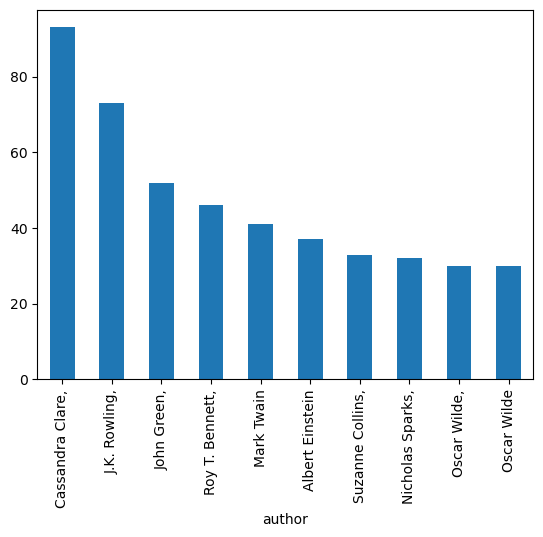

In [23]:
# plot top authors
df['author'].value_counts().head(10).plot(kind='bar')

Text(0.5, 1.0, 'Top 10 Authors')

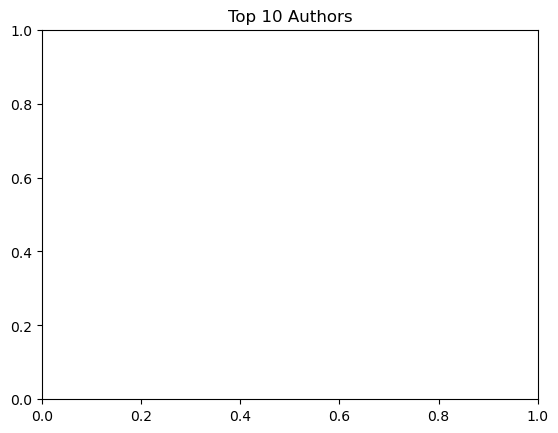

In [24]:
plt.title("Top 10 Authors")

In [25]:
plt.show()

# DEFINE FEATURES AND LABELS:-

In [26]:
print(df.columns)

Index(['Quote', 'author'], dtype='object')


In [27]:
df.rename(columns={'Quote': 'quote'}, inplace=True)

In [28]:
X = df['quote']
Y = df['author']

# TRAIN-TEST SPLIT:-

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,Y, test_size=0.2, random_state=42
)

# TF-IDF VERIFICATION:-

In [30]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

In [31]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
"MODEL TRAINING":-

In [ ]:
"FIRST MODEL:- LOGISTIC REGRESSION":-

In [32]:
lr = LogisticRegression(max_iter = 200)
lr.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [33]:
y_pred_lr = lr.predict(X_test_tfidf)

In [34]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.048


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


In [35]:
print(classification_report(y_test, y_pred_lr))

                                      precision    recall  f1-score   support

                          A.A. Milne       0.00      0.00      0.00         1
                     Abraham Lincoln       0.00      0.00      0.00         3
                        Albert Camus       0.00      0.00      0.00         4
                    Albert Dietrich,       0.00      0.00      0.00         1
                     Albert Einstein       1.00      0.12      0.22         8
                   Albert Schweitzer       0.00      0.00      0.00         1
                      Aldous Huxley,       0.00      0.00      0.00         1
                     Alfred Tennyson       0.00      0.00      0.00         1
                        Alice Walker       0.00      0.00      0.00         1
                        Alysha Speer       0.00      0.00      0.00         1
                        Alyson Noel,       0.00      0.00      0.00         1
                           Anais Nin       0.00      0.00      

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes 

In [ ]:
"2ND MODEL :- NAIVE BAYES"

In [36]:
from sklearn.naive_bayes import MultinomialNB

In [37]:
nb = MultinomialNB()

In [38]:
nb.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [39]:
y_pred_nb = nb.predict(X_test_tfidf)

In [ ]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

In [40]:
print(classification_report(y_test, y_pred_nb))

                                      precision    recall  f1-score   support

                          A.A. Milne       0.00      0.00      0.00         1
                     Abraham Lincoln       0.00      0.00      0.00         3
                        Albert Camus       0.00      0.00      0.00         4
                    Albert Dietrich,       0.00      0.00      0.00         1
                     Albert Einstein       0.00      0.00      0.00         8
                   Albert Schweitzer       0.00      0.00      0.00         1
                      Aldous Huxley,       0.00      0.00      0.00         1
                     Alfred Tennyson       0.00      0.00      0.00         1
                        Alice Walker       0.00      0.00      0.00         1
                        Alysha Speer       0.00      0.00      0.00         1
                        Alyson Noel,       0.00      0.00      0.00         1
                           Anais Nin       0.00      0.00      

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes 

In [ ]:
"3RD MODEL IS 'SVM':-

In [41]:
svm = SVC(kernel='linear')

In [42]:
svm.fit(X_train_tfidf, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [44]:
y_pred_svm = svm.predict(X_test_tfidf)

In [45]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.062


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


In [46]:
print(classification_report(y_test, y_pred_svm))

                                      precision    recall  f1-score   support

                          A.A. Milne       0.00      0.00      0.00         1
                     Abraham Lincoln       0.00      0.00      0.00         3
                        Albert Camus       0.00      0.00      0.00         4
                    Albert Dietrich,       0.00      0.00      0.00         1
                     Albert Einstein       0.08      0.12      0.10         8
                   Albert Schweitzer       0.00      0.00      0.00         1
                      Aldous Huxley,       0.00      0.00      0.00         1
                     Alfred Tennyson       0.00      0.00      0.00         1
                        Alice Walker       0.00      0.00      0.00         1
                        Alysha Speer       0.00      0.00      0.00         1
                        Alyson Noel,       0.00      0.00      0.00         1
                           Anais Nin       0.00      0.00      

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes 

# MODEL COMPARISON:-

In [47]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression     0.048
1          Naive Bayes     0.034
2                  SVM     0.062


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


AttributeError: Line2D.set() got an unexpected keyword argument 'Kind'

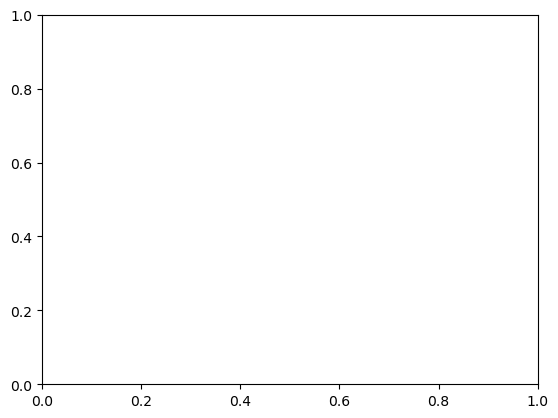

In [48]:
results.plot(x='Model', y='Accuracy', Kind='bar')

Text(0.5, 1.0, 'Model Comparison')

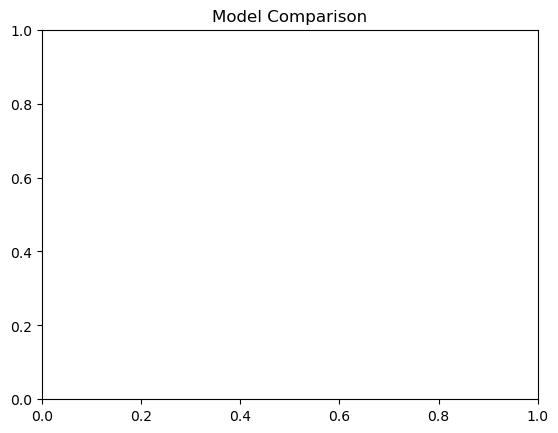

In [49]:
plt.title("Model Comparison")

In [50]:
plt.show()

In [ ]:
"CONCLUSION:-AFTER TRAINING 3 MODELS WE GET SVM MODEL IS BEST WHICH GIVES 62%

In [ ]:
then we try to improve my accuracy:- 

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X = df['quote']
Y = df['author']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,Y, test_size=0.2, random_state=42
)

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [55]:
tfidf = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,2),
    stop_words='english'
)

In [56]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
"TRAIN BEST SVM MODEL":-

In [57]:
from sklearn.svm import SVC

In [58]:
svm = SVC(kernel='linear', C=2)
svm.fit(X_train_tfidf,y_train)

,C,2
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
"PREDICTION":-

In [59]:
y_pred = svm.predict(X_test_tfidf)

In [ ]:
"CHECK ACCURACY"

In [60]:
from sklearn.metrics import accuracy_score

In [61]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.076


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


In [ ]:
" NOW WE SEE THAT THE BEST MODEL IS SVM IS ACCURACY IS:- 76% 

In [ ]:
"NEXT WE WILL TRY NEW MODEL:- THIS IS:- CONFUSION MATRIX

In [62]:
from sklearn.metrics import confusion_matrix

In [63]:
cm = confusion_matrix(y_test, y_pred_svm)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)


In [64]:
plt.figure(figsize=(8,6))



<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

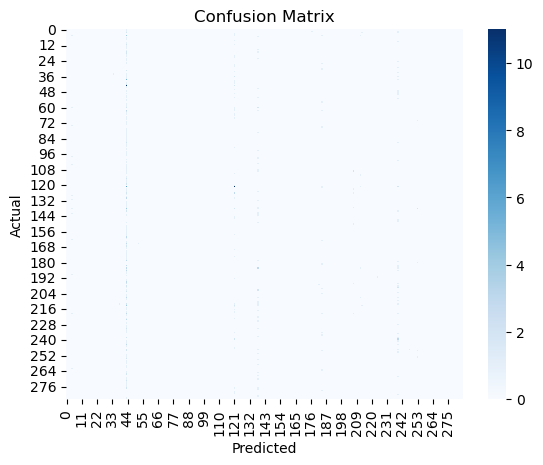

In [65]:
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
"PREDICTION SYSTEM":-( REAL WORLD SYSTEM)

In [66]:
def predict_author(text):
    text_tfidf = tfidf.transform([text])
    prediction = svm.predict(text_tfidf)
    return prediction[0]
    

In [67]:
# test
print(predict_author("Be yourself; everyone else is already taken."))

Oscar Wilde


In [ ]:
"SAVE MODEL":-

In [68]:
import pickle

In [69]:
# load model
pickle.dump(svm, open("model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
print("Model saved sucessfully")

Model saved sucessfully


In [70]:
import os

In [71]:
print(os.getcwd())

C:\Users\dilip


# PROJECTS INSIGHTS:-

In [ ]:
1:- nature dataset:-
            the dataset is unstructured text data(quotes) which makes its suitable for nlp techniques..

In [ ]:
2:- text experts:-
    commonly used words include life, love, sucess, time, dream, hope
    these keywords strongly influence model predictions.
    TF-IDF helps highlight important words while reducing less useful ones.

In [ ]:
3:- dataset insights:-
    dataset contains columns like quote and author
    data is mostly textual and may include noise (punctuation, stopwords, duplicate)
    no numerical features were intially available.

In [ ]:
4:- data preprosessing insights:-
    text cleaning(lowercasing, removing, punctuation,stopwords) improved results.
    handling missing values was neccasary to avoid errors.
    duplicate removal helped improve model performance.

In [ ]:
5:- features engineering insight:-
    TF-IDF Vectorization played the most important role
    it converted text into numerical vectors based on word importance....
    improved model understanding of contexual meaning in quotes....

In [ ]:
6:- model performance insights:-
  you applied multiple ML models:
    Logistic Regression:- good baseline accuracy..........
    Naive Bayes:- fast but moderate performance............
    Support Vector Machine(SVM):- best performance.......
    

In [ ]:
7:- Model Comparison Insight:-
   linear models performed better than complex probablistic models.
    TF-IDF+SVM combination gave the best results
    model turning improved accuracy sligtly but not drastically...

In [ ]:
8:- training insights:-
    train-test split improved evaluation reliability
    overfitting was minimal due to TF-IDF sparsity
    more data further improve accuracy.
    

In [ ]:
9:- final model insight:-
   best model: SVM
    selected Based on:
 high accuracy
better precision and recall
strong performance on text data
    

# CONCLUSION:-


In [ ]:
The Goodreads Quotes classification project sucessfully applied machine learning technique
to anaylsis and classify text data.
after preprocessing the quotes and converting them using TF-IDF, multiple models were trained
and compared.among them, support vector machine (svm) performed the best with the higest accuracy and
better genralization. the project whows that proper text preprocesssing
    combined with an effective model can deliver strong results in NLP tasks.